In [21]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df['life_expec'].max()

np.float64(82.8)

In [4]:
X = df.drop(columns=['country'])

In [7]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)
X_norm[0][0]

np.float64(1.2915323778422956)

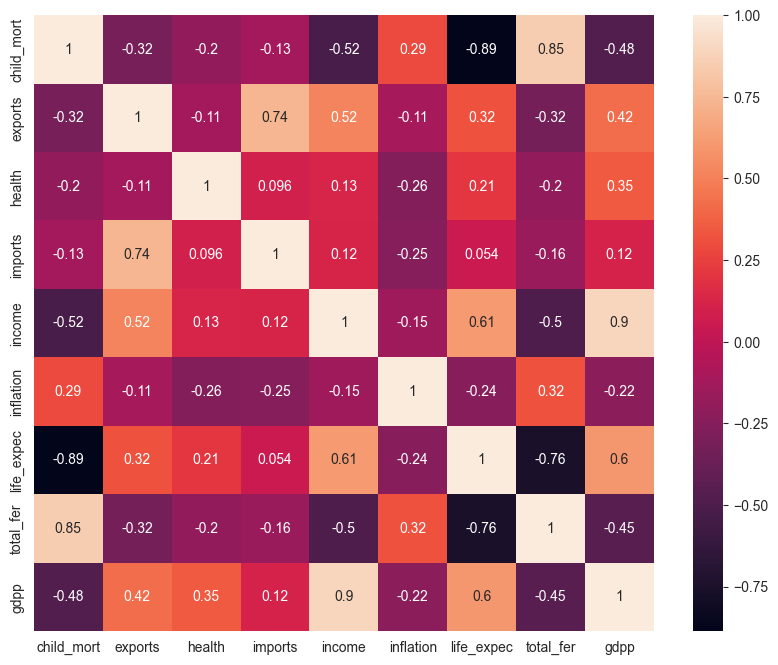

In [15]:
df_norm = pd.DataFrame(X_norm)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [17]:
pca = PCA(n_components=0.9)
principalComponents = pca.fit_transform(df_norm)
principalComponents

array([[-2.91302459e+00,  9.56205755e-02, -7.18118495e-01,
         1.00525464e+00, -1.58310044e-01],
       [ 4.29911330e-01, -5.88155666e-01, -3.33485505e-01,
        -1.16105859e+00,  1.74677321e-01],
       [-2.85225077e-01, -4.55174413e-01,  1.22150481e+00,
        -8.68114503e-01,  1.56474647e-01],
       [-2.93242265e+00,  1.69555507e+00,  1.52504374e+00,
         8.39625014e-01, -2.73208934e-01],
       [ 1.03357587e+00,  1.36658709e-01, -2.25720917e-01,
        -8.47062687e-01, -1.93006961e-01],
       [ 2.24072616e-02, -1.77918658e+00,  8.69997116e-01,
        -3.69668667e-02,  9.81056507e-01],
       [-1.01583737e-01, -5.68251724e-01,  2.42091816e-01,
        -1.46626576e+00, -5.59924282e-02],
       [ 2.34216461e+00, -1.98845915e+00,  1.90344188e-01,
         1.10503778e+00, -7.31192330e-01],
       [ 2.97376366e+00, -7.34688659e-01, -5.19766356e-01,
         1.20544210e+00,  8.35797058e-02],
       [-1.81486997e-01, -4.02865873e-01,  8.67458743e-01,
        -4.38772983e-01

In [19]:
first_ratio = pca.explained_variance_ratio_[0]
print(f"Первая компонента объясняет {first_ratio} дисперсии")

Первая компонента объясняет 0.45951739786095896 дисперсии


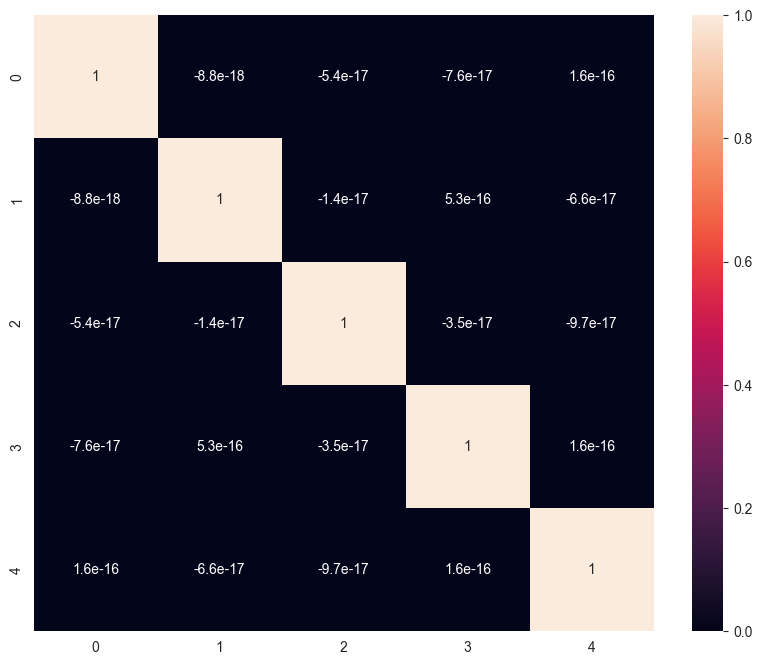

In [20]:
df_pca = pd.DataFrame(principalComponents)
plt.figure(figsize=(10, 8))
sns.heatmap(df_pca.corr(numeric_only=True), annot=True)
plt.show()

<Axes: xlabel='cluster', ylabel='silhouette'>

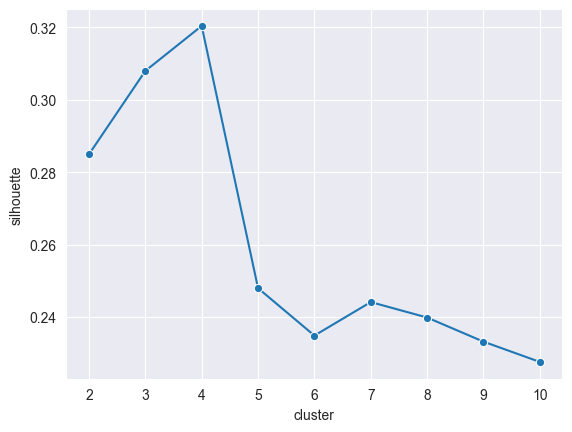

In [23]:
def get_silhouette(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=1)
    k_means.fit(X)
    silhouette = silhouette_score(X, k_means.predict(X))
    return silhouette

silhouette_res = {"silhouette": [], "cluster": []}

for cluster_num in range(2, 11):
    silhouette_res["silhouette"].append(get_silhouette(cluster_num, df_pca))
    silhouette_res["cluster"].append(cluster_num)

silhouette_df = pd.DataFrame(silhouette_res)

sns.set_style("darkgrid")
sns.lineplot(data=silhouette_df, x="cluster", y="silhouette", marker= "o")

In [28]:
k_means =  KMeans(n_clusters=4, random_state=1)
k_means.fit(df_pca)

y_pred = k_means.predict(df_pca)
df['cluster'] = y_pred

In [30]:
max_mort = df.nlargest(5, 'child_mort')[['country','cluster']]
# min по ВВП
min_gdp  = df.nsmallest(5, 'gdpp')[['country','cluster']]

print("Макс детская смертность:\n", max_mort)
print("Мин ВВП на душу:\n",      min_gdp)

Макс детская смертность:
                       country  cluster
66                      Haiti        0
132              Sierra Leone        0
32                       Chad        0
31   Central African Republic        0
97                       Mali        0
Мин ВВП на душу:
               country  cluster
26            Burundi        0
88            Liberia        0
37   Congo, Dem. Rep.        0
112             Niger        0
132      Sierra Leone        0


In [31]:
df.nsmallest(3, 'life_expec')[['country','cluster']]

,country,cluster
66,Haiti,0
87,Lesotho,0
31,Central African Republic,0
